# 10K Autoencoder Retraining Pipeline

This notebook perfectly replicates the original 10K Autoencoder architecture while updating the data pipeline and checkpointing logic to strictly match the standardized 10K VAE notebook for fair comparison.


In [1]:
import os
import random
import hashlib
import json
import shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from IPython.display import FileLink

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Load Dataset & Exact Split


In [2]:
!pip install -q datasets
from datasets import load_dataset
dataset = load_dataset("evilsocket/alucard-sprites")
train_data = dataset["train"]

def image_hash(image):
    pixels = np.asarray(image.convert("RGBA"), dtype=np.uint8)
    return hashlib.sha256(pixels.tobytes()).hexdigest()

all_hashes = []
seen_hashes = set()
for i, item in enumerate(train_data):
    h = image_hash(item["image"])
    if h not in seen_hashes:
        seen_hashes.add(h)
        all_hashes.append(i)

unique_dataset = train_data.select(all_hashes)

SEED = 42
unique_dataset = unique_dataset.shuffle(seed=SEED)

TRAIN_SIZE = 9_000
VAL_SIZE = 1_000
TEST_SIZE = 1_000
TOTAL_SIZE = TRAIN_SIZE + VAL_SIZE + TEST_SIZE

clean_dataset = unique_dataset.select(range(TOTAL_SIZE))
train_dataset = clean_dataset.select(range(0, TRAIN_SIZE))
val_dataset = clean_dataset.select(range(TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE))
test_dataset = clean_dataset.select(range(TRAIN_SIZE + VAL_SIZE, TOTAL_SIZE))

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/196M [00:00<?, ?B/s]

data/train-00003-of-00006.parquet:   0%|          | 0.00/197M [00:00<?, ?B/s]

data/train-00004-of-00006.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

data/train-00005-of-00006.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/312550 [00:00<?, ? examples/s]

Training: 9000
Validation: 1000
Test: 1000


In [3]:
def data_generator(hf_dataset):
    for item in hf_dataset:
        image = item["image"]
        image = image.convert("RGBA")
        image_np = np.array(image, dtype=np.float32) / 255.0
        yield (image_np, image_np)

BATCH_SIZE = 32

def create_tf_dataset(hf_dataset):
    return tf.data.Dataset.from_generator(
        lambda: data_generator(hf_dataset),
        output_signature=(
            tf.TensorSpec(shape=(128, 128, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(128, 128, 4), dtype=tf.float32)
        )
    )

train_tf = create_tf_dataset(train_dataset).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)
val_tf = create_tf_dataset(val_dataset).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)
test_tf = create_tf_dataset(test_dataset).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_originals = []
for images, _ in test_tf.take(2): # load 64 images for quick eval plotting
    test_originals.append(images.numpy())
test_originals = np.concatenate(test_originals, axis=0)
print("Pipelines ready.")


I0000 00:00:1787390141.352405      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787390141.358458      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Pipelines ready.


## 2. 10K Autoencoder Architecture (v1)


In [4]:
# Encoder
encoder = keras.Sequential([
    layers.Input(shape=(128, 128, 4)),
    layers.Conv2D(32, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(64, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(128, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(256, 3, activation="relu", padding="same", strides=2),
], name="encoder")

# Decoder
decoder = keras.Sequential([
    layers.Input(shape=(8, 8, 256)),
    layers.Conv2DTranspose(128, 4, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(64, 4, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(32, 4, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(4, 4, activation="sigmoid", padding="same", strides=2)
], name="decoder")

# Standard Autoencoder Model (using tf.square to avoid keras compat issues)
class Autoencoder(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(Autoencoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, inputs):
        encoded = self.encoder(inputs)
        return self.decoder(encoded)

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            encoded = self.encoder(x)
            reconstruction = self.decoder(encoded)
            loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=(1, 2, 3)))
            
        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        x, _ = data
        encoded = self.encoder(x)
        reconstruction = self.decoder(encoded)
        loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=(1, 2, 3)))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

ae = Autoencoder(encoder, decoder)
ae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
ae.build((None, 128, 128, 4))
ae.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 8, 8, 256)      │       388,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 128, 128, 4)    │       690,404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,079,108 (4.12 MB)

 Trainable params: 1,079,108 (4.12 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training & Checkpointing


In [5]:
MODEL_DIR = "/kaggle/working/AE_10K_Results"
os.makedirs(MODEL_DIR, exist_ok=True)

class SaveHistoryCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        hist_path = os.path.join(MODEL_DIR, "history.json")
        history = json.load(open(hist_path, "r")) if os.path.exists(hist_path) else {}
        for k, v in logs.items():
            history.setdefault(k, []).append(float(v))
        with open(hist_path, "w") as f:
            json.dump(history, f)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(filepath=os.path.join(MODEL_DIR, "latest.weights.h5"), save_weights_only=True),
    keras.callbacks.ModelCheckpoint(filepath=os.path.join(MODEL_DIR, "best.weights.h5"), save_best_only=True, monitor="val_loss", save_weights_only=True),
    SaveHistoryCallback()
]

history = ae.fit(
    train_tf,
    steps_per_epoch=282, # 9000/32
    epochs=50,
    validation_data=val_tf,
    validation_steps=32,
    callbacks=callbacks
)


Epoch 1/50


2026-08-22 09:15:47.338474: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-22 09:15:47.477684: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  5/282 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 13224.8973

I0000 00:00:1787390150.082441     166 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - loss: 2694.2332 - val_loss: 1082.5614
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 876.8843 - val_loss: 788.7055
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 712.9050 - val_loss: 677.4124
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 629.9924 - val_loss: 593.1458
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - loss: 567.2040 - val_loss: 541.6136
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 525.2190 - val_loss: 512.6690
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 494.7106 - val_loss: 472.1833
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 438.8566 - val_loss: 413.8903
Epoch 9/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 462.0995 - val_loss: 421.0312
Epoch 10/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 393.4855 - val_loss: 376.8191
Epoch 11/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 367.1439 - val_loss: 361.

## 4. Evaluation & Download


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step 


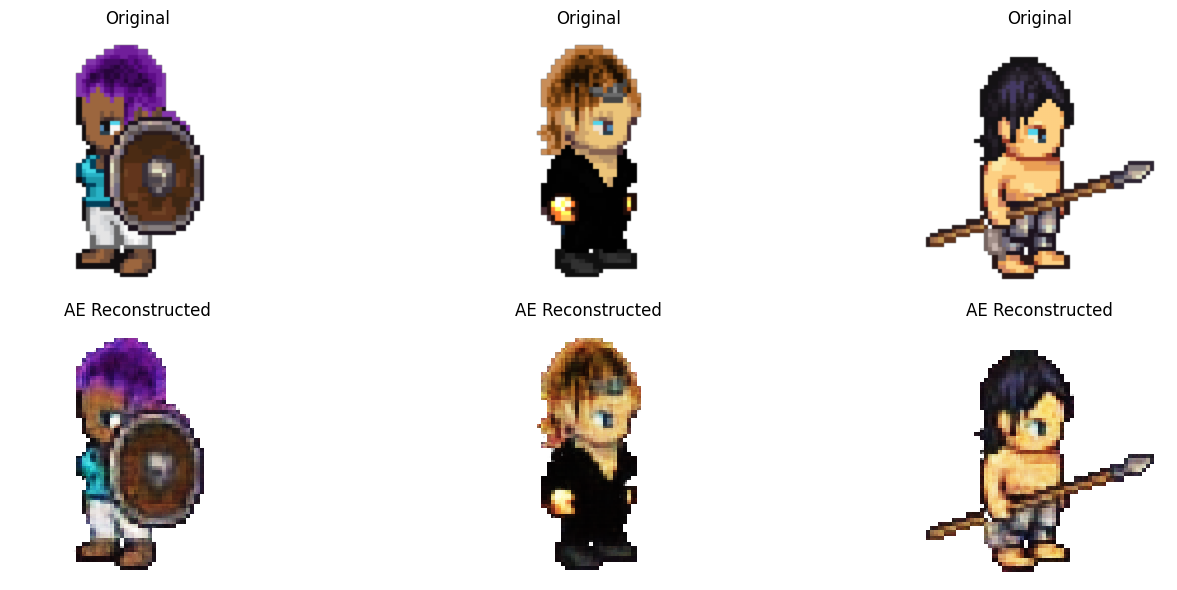

Created /kaggle/working/AE_10K_Results.zip!
Click the link below to download your files:


/kaggle/working/AE_10K_Results.zip

In [6]:
# Evaluate on Test Set
test_reconstructions = ae.predict(test_originals)

random_indices = random.sample(range(len(test_originals)), 3)
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for i, idx in enumerate(random_indices):
    axes[0, i].imshow(test_originals[idx])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(test_reconstructions[idx])
    axes[1, i].set_title("AE Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# Zip and download
zip_path = "/kaggle/working/AE_10K_Results"
shutil.make_archive(zip_path, 'zip', MODEL_DIR)

print(f"Created {zip_path}.zip!")
print("Click the link below to download your files:")
FileLink(r'AE_10K_Results.zip')


In [7]:
import shutil
import os
import json
import numpy as np
import tensorflow as tf
from PIL import Image

MODEL_DIR = "/kaggle/working/AE_10K_Results"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Saving comprehensive model artifacts...")

# 1. Save individual weights
ae.save_weights(os.path.join(MODEL_DIR, "ae_10k_final.weights.h5"))
encoder.save_weights(os.path.join(MODEL_DIR, "encoder_10k_final.weights.h5"))
decoder.save_weights(os.path.join(MODEL_DIR, "decoder_10k_final.weights.h5"))

# 2. Save Model Summary
with open(os.path.join(MODEL_DIR, "ae_model_summary.txt"), "w") as f:
    ae.summary(print_fn=lambda x: f.write(x + "\n"))
    encoder.summary(print_fn=lambda x: f.write(x + "\n"))
    decoder.summary(print_fn=lambda x: f.write(x + "\n"))

# 3. Save Architecture Info & Config
arch_info = {
    "input_shape": [128, 128, 4],
    "latent_shape": [8, 8, 256],
    "encoder_layers": [layer.name for layer in encoder.layers],
    "decoder_layers": [layer.name for layer in decoder.layers]
}
with open(os.path.join(MODEL_DIR, "architecture_info.json"), "w") as f:
    json.dump(arch_info, f, indent=4)

config_info = {
    "epochs": 50,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss": "MSE"
}
with open(os.path.join(MODEL_DIR, "experiment_config.json"), "w") as f:
    json.dump(config_info, f, indent=4)

# 4. Save Evaluation Metrics
test_reconstructions = ae.predict(test_originals)
test_mse = float(np.mean(np.square(test_originals - test_reconstructions)))
test_psnr = float(np.mean(tf.image.psnr(test_originals, test_reconstructions, max_val=1.0).numpy()))
metrics = {
    "test_mse": test_mse,
    "test_psnr": test_psnr
}
with open(os.path.join(MODEL_DIR, "evaluation_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# 5. Save Reconstructions Grid Images
recon_dir = os.path.join(MODEL_DIR, "reconstructions")
os.makedirs(recon_dir, exist_ok=True)
random_indices = np.random.choice(len(test_originals), 5, replace=False)
for i, idx in enumerate(random_indices):
    orig_img = (test_originals[idx] * 255).astype(np.uint8)
    recon_img = (test_reconstructions[idx] * 255).astype(np.uint8)
    Image.fromarray(orig_img).save(os.path.join(recon_dir, f"sample_{i}_original.png"))
    Image.fromarray(recon_img).save(os.path.join(recon_dir, f"sample_{i}_reconstruction.png"))

print("All comprehensive files saved to", MODEL_DIR)

# 6. Zip and download
zip_path = "/kaggle/working/AE_10K_Results"
shutil.make_archive(zip_path, 'zip', MODEL_DIR)

print(f"Created {zip_path}.zip with ALL comprehensive files!")
from IPython.display import FileLink
FileLink(r'AE_10K_Results.zip')


Saving comprehensive model artifacts...


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
All comprehensive files saved to /kaggle/working/AE_10K_Results
Created /kaggle/working/AE_10K_Results.zip with ALL comprehensive files!


/kaggle/working/AE_10K_Results.zip